In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bartoszpachala/reviews/Reviews.csv


# Food Reviews Analysis
### The project focuses on analyzing negative reviews (1–2 stars) to identify the most common issues reported by users.

568454
Score
1     9.19
2     5.24
3     7.50
4    14.19
5    63.88
Name: count, dtype: float64


<Axes: xlabel='Score'>

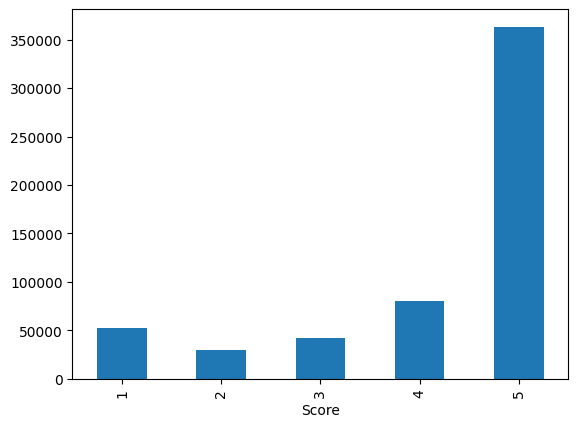

In [2]:
reviews = pd.read_csv("/kaggle/input/datasets/bartoszpachala/reviews/Reviews.csv")
stars = reviews['Score'].value_counts().sort_index()

sum_of_reviews = len(reviews['Score'])
print(sum_of_reviews)

print(((stars / sum_of_reviews) * 100).round(2).sort_index())
negative_opinions = reviews[(reviews['Score'] == 1) | (reviews['Score'] == 2)]
other_opinions = reviews[~reviews['Score'].isin([1,2])]

stars.plot(kind="bar")

### Dataset is unbalanced, most of the scores are 5/5, when negatives(1 or 2 out of 5) are only around 14% 
### That means analysis will be based on smaller, but meaningfull portion of data which tells us about customers problems.

In [3]:
character_count = reviews['Text'].str.len()
print("characters mean " + str(character_count.mean().round()))
print("characters max " + str(character_count.max()))
print("characters min " + str(character_count.min()))

words_count = reviews['Text'].str.split().str.len()

print("words mean " + str(words_count.mean().round()))
print("words max " + str(words_count.max()))
print("words min " + str(words_count.min()))

# Comparasing negative and non-negative opinions

negative_character_count = negative_opinions['Text'].str.len()
negative_words_count = negative_opinions['Text'].str.split().str.len()

other_character_count = other_opinions['Text'].str.len()
other_words_count = other_opinions['Text'].str.split().str.len()


print("negative character mean " + str(negative_character_count.mean().round()))
print("negative words mean " + str(negative_words_count.mean().round()))
print("other character mean " + str(other_character_count.mean().round()))
print("other words mean " + str(other_words_count.mean().round()))


characters mean 436.0
characters max 21409
characters min 12
words mean 80.0
words max 3432
words min 3
negative character mean 483.0
negative words mean 88.0
other character mean 428.0
other words mean 79.0


### Reviews are relatively long, and usually around 80 words which provides rich textual information for analysis.
### Negative opinions tend to be slightly longer than other ones, which can suggest that with negative opinions people 

In [4]:
stop_words = set(stopwords.words('english'))
clean_negative_opinions = negative_opinions['Text'] \
    .str.lower() \
    .str.replace(r'[^a-z\s]', '', regex=True) \
    .str.split() \
    .explode()

filtered_words = clean_negative_opinions[~clean_negative_opinions.isin(stop_words)]
filtered_words = filtered_words[filtered_words.str.len() > 2]

word_count = filtered_words.value_counts()

print(word_count.head(20))


Text
like       43673
product    31598
taste      30957
one        27372
would      26768
coffee     21790
food       21769
good       21048
flavor     19637
dont       17508
even       16327
get        16020
tea        15729
buy        14910
really     14214
much       13802
amazon     13060
tried      11947
first      11763
box        11519
Name: count, dtype: int64


### Words like "taste" and "flavor" frequently appear in negative reviews, indicating that product taste is an important factor in user dissatisfaction. 
### However, individual words do not provide enough context to determine whether the sentiment is negative or positive, which motivates further analysis using multi-word expressions.

In [7]:
negative_opinions_vectoring = negative_opinions["Text"] \
    .str.lower() \
    .str.replace(r"<br\s*/?>", " ", regex=True) \
    .str.replace(r"\bbr\b", " ", regex=True) \
    .str.replace(r"http\S+|www\S+", " ", regex=True)


print(negative_opinions_vectoring)

1         product arrived labeled as jumbo salted peanut...
3         if you are looking for the secret ingredient i...
12        my cats have been happily eating felidae plati...
16        i love eating them and they are good for watch...
26        the candy is just red , no flavor . just  plan...
                                ...                        
568433    i just bought this soup today at my local groc...
568434    this soup is mostly broth. although it has a k...
568435    it is mostly broth, with the advertised 3/4 cu...
568446    i had ordered some of these a few months back ...
568450    i'm disappointed with the flavor. the chocolat...
Name: Text, Length: 82037, dtype: object


In [8]:
vectorizer = CountVectorizer(analyzer="word", ngram_range=(2,2), stop_words="english")
sample = negative_opinions_vectoring.sample(50000, random_state=42)
X = vectorizer.fit_transform(sample)
bigrams = vectorizer.get_feature_names_out()
bigrams_sum = X.sum(axis=0).A1

In [10]:
result = list(zip(bigrams, bigrams_sum))
sorted_result = sorted(result, key=lambda x: x[1], reverse=True)
for i in range(20):
    print(sorted_result[i])

('taste like', np.int64(2624))
('tastes like', np.int64(2094))
('don know', np.int64(1617))
('waste money', np.int64(1409))
('dog food', np.int64(1273))
('tasted like', np.int64(1009))
('science diet', np.int64(996))
('gluten free', np.int64(983))
('green tea', np.int64(974))
('grocery store', np.int64(952))
('cat food', np.int64(927))
('peanut butter', np.int64(922))
('taste good', np.int64(870))
('ve tried', np.int64(860))
('don like', np.int64(846))
('coconut water', np.int64(769))
('expiration date', np.int64(758))
('customer service', np.int64(712))
('don think', np.int64(683))
('cup coffee', np.int64(645))


### Bigram analysis shows that **taste is one of the most important factors** in negative reviews.
### Users often mention taste and flavor when describing problems with products.

### Phrases like "waste money" suggest that customers feel the **product is not worth the price**.

### We can also see issues related to specific product types (like pet food or drinks), expiration dates, and customer service.

### However, bigrams alone do not always show clear sentiment, because some phrases (like "taste good") can still appear in negative reviews